# Plot the SEDs of the non-parametric customized models

In [29]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from fgbuster.observation_helpers import *
from fgbuster.component_model import CMB, Dust, Synchrotron

from micmac import fgs_freq_maps_from_customized_model_nonparam

In [30]:
nside_map = 1
nside_spv = 1
instr_name = 'LiteBIRD'

In [31]:
instrument = get_instrument(instr_name)

In [32]:
freq_maps_s0 = get_observation(instrument=instrument, sky='s0', nside=1)
freq_maps_d0 = get_observation(instrument=instrument, sky='d0', nside=1)

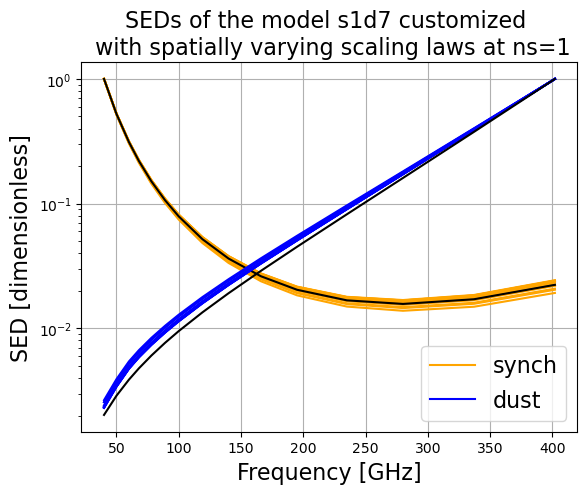

In [34]:
models = [['s1'], ['d7']]
cols = ['orange', 'blue']
ref_freqs = [0, -1]
labels = ['synch', 'dust']
stokes_idx = 1
freq_maps_for_SEDs_reference = [freq_maps_s0, freq_maps_d0]

for i, model in enumerate(models):
    # get input freq maps customized with less spv of SEDs
    freq_maps_fgs_spvns1, mixing_mat_fgs_spvns1 = fgs_freq_maps_from_customized_model_nonparam(nside_map, nside_spv, instrument, fgs_models=model, idx_ref_freq=6, return_mixing_mat=True)

    label_added = False
    for pix_idx, _ in enumerate(freq_maps_fgs_spvns1[0, 0, :]):
        if not label_added:
            plt.plot(instrument.frequency, freq_maps_fgs_spvns1[:, stokes_idx, pix_idx]/freq_maps_fgs_spvns1[ref_freqs[i], stokes_idx, pix_idx], color=cols[i], label=labels[i])
            label_added = True
        else:
            plt.plot(instrument.frequency, freq_maps_fgs_spvns1[:, stokes_idx, pix_idx]/freq_maps_fgs_spvns1[ref_freqs[i], stokes_idx, pix_idx], color=cols[i])

    # reference MBB nd PL (from d0)
    plt.plot(instrument.frequency, freq_maps_for_SEDs_reference[i][:, stokes_idx, 0]/freq_maps_for_SEDs_reference[i][ref_freqs[i], stokes_idx, 0], color='black')  #, label='d0')

plt.title('SEDs of the model '+str(models[0][0])+str(models[1][0])+' customized \n with spatially varying scaling laws at ns=1',fontsize=16)
plt.ylabel('SED [dimensionless]', fontsize=16)
plt.xlabel('Frequency [GHz]', fontsize=16)
plt.yscale('log')
plt.legend(fontsize=16)
# plt.legend()
plt.grid()